In [ ]:
!pip install roboflow

from roboflow import Roboflow
from google.colab import userdata
RF_API_KEY = userdata.get('RF_API_KEY')
rf = Roboflow(api_key=RF_API_KEY)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 184.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
project = rf.workspace("caretech-v2").project("v2-caretech-combined-dataset")
version = project.version(1)
dataset = version.download("yolo26")

In [ ]:
food_to_id = {
    'adobo': 0, 'almond-jelly': 1, 'apple': 2, 'apple-pie': 3, 'babi-guling': 4,
    'bagel': 5, 'bak-kut-teh': 6, 'ball-shaped-bun-with-pork': 7,
    'barbecued-red-pork-in-sauce-with-rice': 8, 'bean-curd-family-style': 9,
    'beef-bowl': 10, 'beef-curry': 11, 'beef-noodle-soup': 12, 'bibimbap': 13,
    'boiled-chicken-and-vegetables': 14, 'boiled-fish': 15,
    'boned-sliced-hainan-style-chicken-with-marinated-rice': 16,
    'braised-pork-meat-ball-with-napa-cabbage': 17, 'broiled-eel-bowl': 18,
    'brownie': 19, 'bubur-ayam': 20, 'cabbage-roll': 21, 'caesar-salad': 22,
    'champon': 23, 'charcoal-boiled-pork-neck': 24, 'chicken-cutlet': 25,
    'chicken-n-egg-on-rice': 26, 'chicken-nugget': 27,
    'chicken-rice-curry-with-coconut': 28, 'chilled-noodle': 29, 'chop-suey': 30,
    'churro': 31, 'clear-soup': 32, 'coconut-milk-flavored-crepes-with-shrimp-and-beef': 33,
    'coconut-milk-soup': 34, 'cold-tofu': 35, 'crape': 36, 'cream-puff': 37,
    'crispy-noodles': 38, 'croissant': 39, 'croquette': 40, 'crullers': 41,
    'curry-puff': 42, 'custard-tart': 43, 'cutlet-curry': 44, 'dipping-noodles': 45,
    'dish-consisting-of-stir-fried-potato-eggplant-and-green-pepper': 46,
    'doughnut': 47, 'dried-fish': 48, 'dry-curry': 49, 'eels-on-rice': 50,
    'egg-sunny-side-up': 51, 'egg-tart': 52, 'eggplant-with-garlic-sauce': 53, 'fajitas': 54,
    'fish-and-chips': 55, 'fish-curry': 56, 'fish-sauce-fried-chicken': 57,
    'french-toast': 58, 'fried-chicken': 59, 'fried-chicken': 60,
    'fried-fish': 61, 'fried-mussel-pancakes': 62, 'fried-noodle': 63,
    'fried-pork-dumplings-served-in-soup': 64, 'fried-pork-in-scoop': 65,
    'fried-rice': 66, 'fried-shrimp': 67, 'fried-spring-rolls': 68,
    'ginger-pork-saute': 69, 'glutinous-rice-balls': 70, 'goya-chanpuru': 71,
    'gratin': 72, 'green-curry': 73, 'green-salad': 74, 'grilled-chicken': 75,
    'grilled-eggplant': 76, 'grilled-pacific-saury': 77, 'gulai': 78,
    'hambarg-steak': 79, 'hamburger': 80, 'haupia': 81,
    'hot-and-sour-fish-and-vegetable-ragout': 82, 'hot-and-sour-soup': 83,
    'hot-dog': 84, 'hot-pot': 85, 'hue-beef-rice-vermicelli-soup': 86,
    'inarizushi': 87, 'jambalaya': 88, 'japanese-style-pancake': 89,
    'japanese-tofu-and-vegetable-chowder': 90, 'jiaozi': 91, 'jjigae': 92,
    'kamameshi': 93, 'kaya-toast': 94, 'khao-soi': 95,
    'kinpira-style-sauteed-burdock': 96, 'kushikatu': 97, 'laksa': 98,
    'lamb-kebabs': 99, 'lasagna': 100, 'laulau': 101, 'lightly-roasted-fish': 102,
    'loco-moco': 103, 'lumpia': 104, 'macaroni-salad': 105, 'malasada': 106,
    'mango-pudding': 107, 'meat-loaf': 108, 'mie-ayam': 109, 'minced-pork-rice': 110,
    'minestrone': 111, 'miso-soup': 112, 'mixed-rice': 113, 'moon-cake': 114,
    'muffin': 115, 'mushroom-risotto': 116, 'nachos': 117, 'nanbanzuke': 118,
    'natto': 119, 'noodles-with-fish-curry': 120, 'oatmeal': 121, 'oden': 122,
    'okinawa-soba': 123, 'omelet': 124, 'orange': 125, 'oshiruko': 126,
    'oxtail-soup': 127, 'paella': 128, 'pancake': 129, 'parfait': 130, 'pho': 131,
    'pilaf': 132, 'pizza': 133, 'pizza-toast': 134, 'popcorn': 135,
    'pork-belly': 136, 'pork-cutlet': 137, 'pork-satay': 138,
    'pork-sticky-noodles': 139, 'pork-with-lemon': 140, 'pot-au-feu': 141,
    'potage': 142, 'potato-salad': 143, 'raisin-bread': 144, 'ramen-noodle': 145,
    'rare-cheese-cake': 146, 'rice': 147, 'rice-ball': 148, 'rice-crispy-pork': 149,
    'rice-gratin': 150, 'rice-gruel': 151, 'rice-vermicelli': 152,
    'rice-with-roast-duck': 153, 'roast-chicken': 154, 'roast-duck': 155,
    'roll-bread': 156, 'salmon': 157, 'salt-and-pepper-fried-shrimp-with-shell': 158,
    'samul': 159, 'sandwiches': 160, 'sashimi': 161, 'sausage': 162,
    'sauteed-spinach': 163, 'sauteed-vegetables': 164, 'scone': 165,
    'scrambled-egg': 166, 'shortcake': 167, 'shrimp-patties': 168,
    'shrimp-with-chill-source': 169, 'simmered-pork': 170,
    'small-steamed-savory-rice-pancake': 171, 'soba-noodle': 172,
    'sour-prawn-soup': 173, 'spaghetti': 174, 'spaghetti-meat-sauce': 175,
    'spam-musubi': 176, 'spicy-chicken-salad': 177, 'spicy-chili-flavored-tofu': 178,
    'steak': 179, 'steamed-egg-hotchpotch': 180, 'steamed-meat-dumpling': 181,
    'steamed-rice-roll': 182, 'steamed-spareribs': 183, 'stew': 184,
    'stewed-pork-leg': 185, 'stinky-tofu': 186, 'stir-fried-beef': 187,
    'stir-fried-chicken': 188, 'stir-fried-mixed-vegetables': 189, 'sukiyaki': 190,
    'sushi': 191, 'sushi-bowl': 192, 'sweet-and-sour-pork': 193, 'tacos': 194,
    'takoyaki': 195, 'tanmen': 196, 'tempura': 197, 'tempura-bowl': 198,
    'tempura-udon': 199, 'tensin-noodle': 200, 'teriyaki-grilled-fish': 201,
    'thai-papaya-salad': 202, 'tiramisu': 203, 'toast': 204, 'tortilla': 205,
    'trunip-pudding': 206, 'twice-cooked-pork': 207, 'udon-noodle': 208,
    'vegetable-tempura': 209, 'vermicelli-noodles-with-snails': 210, 'waffle': 211,
    'xiao-long-bao': 212, 'yakitori': 213, 'yellow-curry': 214, 'zha-jiang-mian': 215
}

In [ ]:
import os
from pathlib import Path

DATASET_PATH = Path(dataset.location)

TRAIN_IMAGES = DATASET_PATH / "train" / "images"
TRAIN_LABELS = DATASET_PATH / "train" / "labels"

VAL_IMAGES = DATASET_PATH / "valid" / "images"
VAL_LABELS = DATASET_PATH / "valid" / "labels"

TEST_IMAGES = DATASET_PATH / "test" / "images"
TEST_LABELS = DATASET_PATH / "test" / "labels"

print("Train images:", sum(1 for f in TRAIN_IMAGES.iterdir() if f.is_file()))
print("Train images:", sum(1 for f in TRAIN_IMAGES.iterdir() if f.is_file()))

print("Val images:", sum(1 for f in VAL_IMAGES.iterdir() if f.is_file()))
print("Val images:", sum(1 for f in VAL_IMAGES.iterdir() if f.is_file()))

print("Test images:", sum(1 for f in TEST_IMAGES.iterdir() if f.is_file()))
print("Test images:", sum(1 for f in TEST_IMAGES.iterdir() if f.is_file()))


Train images: 20508
Train images: 20508
Val images: 5821
Val images: 5821
Test images: 2949
Test images: 2949


In [ ]:
from collections import Counter
import glob

def class_count(label_dir):
    counts = Counter()
    for lf in glob.glob(os.path.join(label_dir, "*.txt")):
        with open(lf) as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                try:
                    cid = int(parts[0])
                except ValueError:
                    continue
                counts[cid] += 1
    return counts

def count_all_classes():
  counts = Counter()
  for f in DATASET_PATH.rglob('*.txt'):
    for line in f.open():
      parts = line.strip().split()
      if not parts:
        continue

      try:
        cid = int(parts[0])

      except ValueError:
        continue
      counts[cid] += 1
  return counts

train_counts = class_count(TRAIN_LABELS)
print("Train class IDs:", sorted(train_counts.keys()))
print("Number of classes", len(train_counts.keys()))
print("Class per ID", train_counts)


Train class IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215]
Number of cl

In [ ]:
import matplotlib.pyplot as plt

def plot_class_distribution(counts_data):
  class_ids = sorted(counts_data.keys())
  counts = [counts_data[cid] for cid in class_ids]

  plt.figure(figsize=(15, 6)) # Adjust figure size for better readability
  plt.bar(class_ids, counts)

  plt.xticks(class_ids, rotation=90, fontsize=8) # Rotate and adjust font size for x-axis labels
  plt.xlabel("Class ID", fontsize=10)
  plt.ylabel("Number of Labels", fontsize=10)
  plt.title("Class Distribution - Labels per Class", fontsize=12)

  plt.tight_layout()
  plt.show()


In [ ]:
from collections import defaultdict

# function to get all the files of all classes
def get_class_files(label_dir: Path):
    files = defaultdict(set)
    for f in label_dir.iterdir():
      if not f.is_file():
          continue

      with open(f) as fh:
          for line in fh:
              parts = line.strip().split()

              if not parts:
                  continue

              try:
                  cid = int(parts[0])
              except ValueError:
                  continue

              imageFile = f.parent.parent / "images" / f.name.replace(".txt", ".jpg")

              files[cid].add(imageFile)

    return files

In [ ]:
from random import sample

# a function to ablate a given class or all and percentage
def ablate(files_dict: dict, percentage: float, cid: int = None):
    files_to_delete = []
    if not cid:
      for current_cid, files in files_dict.items():
        k = int(len(files) * percentage)
        files_to_delete.extend(sample(sorted(files), k))
    else:
      k = int(len(files_dict[cid]) * percentage)
      files_to_delete.extend(sample(sorted(files_dict[cid]), k))

    for f in files_to_delete:
      (f.parent.parent / "labels" / f.name.replace(".jpg", ".txt")).unlink()
      (f.parent.parent / "images" / f.name).unlink()


# a function to ablate the entire dataset by a given percentage
def ablate_all_sets(percentage: float, cid: int = None):
    label_dirs = [TRAIN_LABELS, VAL_LABELS, TEST_LABELS]

    for label_dir in label_dirs:
        files = get_class_files(label_dir)
        if not cid:
          ablate(files, percentage)
        else:
          ablate(files, percentage, cid)

In [ ]:
# we have to delete meat-loaf, its a bad class
ablate_all_sets(1, food_to_id['meat-loaf'])

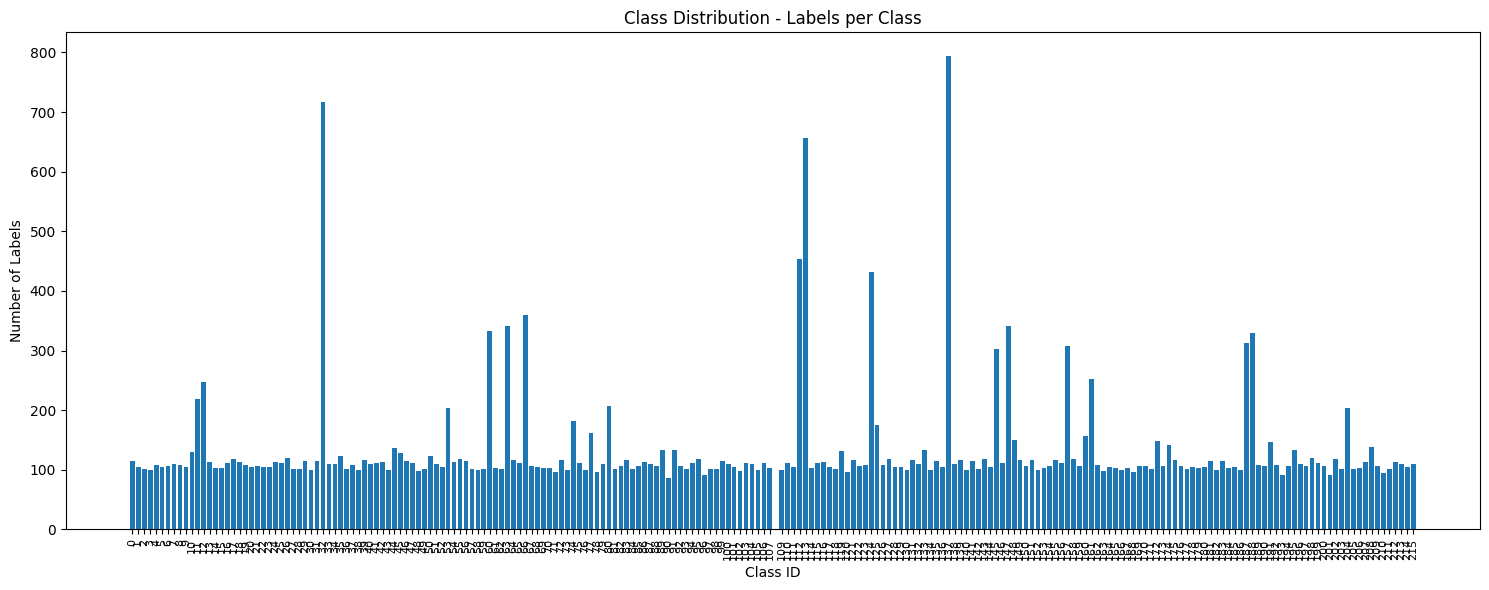

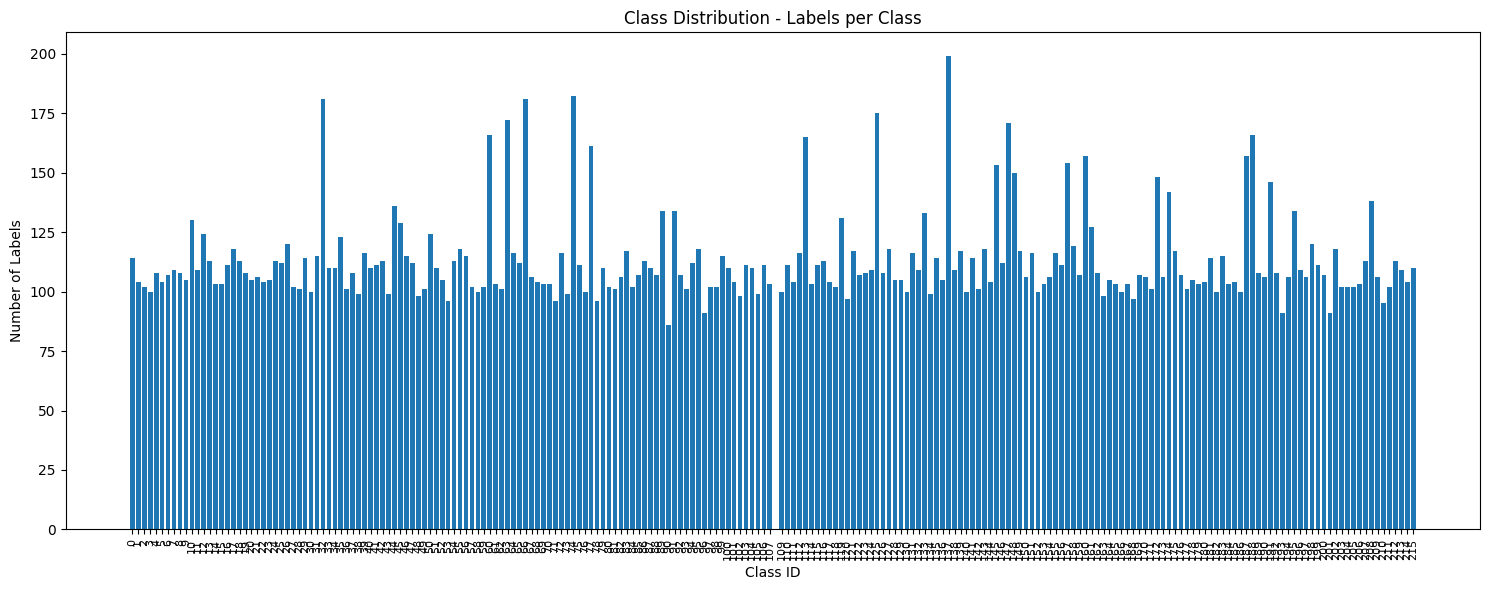

In [ ]:
# pre balancing
counts = count_all_classes()
plot_class_distribution(counts)

for cid, count in counts.items():
  while count > 200:
    ablate_all_sets(0.5, cid)
    counts = count_all_classes()
    count = counts[cid]

# post balancing
counts_after_ablation = count_all_classes()
plot_class_distribution(counts)

In [ ]:
# ablation as well
ablate_all_sets(0.1)

#### Underperforming Classes
(valid), <50%

*   apple 37.0%
*   beef-noodle-soup 56.0%
* chicken-cutlet 32.0%
* crape 41.0%
* egg-sunny-side-up 51.0%
* fried-fish 32.0%
* green_salad 53.0%
* grilled_eggplant 19.0%
*bjapanese-tofu-and-vegetable-chowder 42.0%
* miso-soup 45.0%
* mixed-rice 39.0%
* nanbanzuke 53.0%
* orange 24.0%
* pork-cutlet 43.0%
* pork-with-lemon 35.0%
* stewed-pork-leg 28.0%
* teriyaki-grilled-fish 56.0%
* torilla 52.0%
* vegetable-tempura 46.0%
* yellow-curry 39.0%


In [ ]:
underperforming_classes = [
    'apple',
    'beef-noodle-soup',
    'chicken-cutlet',
    'crape',
    'egg-sunny-side-up',
    'fried-fish',
    'green-salad',
    'grilled-eggplant',
    'japanese-tofu-and-vegetable-chowder',
    'miso-soup',
    'mixed-rice',
    'nanbanzuke',
    'orange',
    'pork-cutlet',
    'pork-with-lemon',
    'stewed-pork-leg',
    'teriyaki-grilled-fish',
    'tortilla',
    'vegetable-tempura',
    'yellow-curry'
]

In [ ]:
import numpy as np
import albumentations as A
import cv2
import uuid
import os
from pathlib import Path

compose_transform = A.Compose([
    A.LongestMaxSize(max_size=640),
    A.PadIfNeeded(min_height=640, min_width=640),
    A.Affine(
        scale=(0.8, 1.2),
        translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)},
        shear={"x": (-10, 10), "y": (-10, 10)},
        rotate=(-10, 10)
        )
], bbox_params=A.BboxParams(format='yolo', label_fields=['bbox_labels']))

# Function to apply transformation to an image and its bounding boxes
def transform_image_and_boxes(image: np.ndarray, bboxes: list):
    labels = [bbox[4] for bbox in bboxes]
    boxes_coords = [bbox[:4] for bbox in bboxes]

    transformed = compose_transform(image=image, bboxes=boxes_coords, bbox_labels=labels)
    transformed_image = transformed['image']
    transformed_bboxes = transformed['bboxes']
    transformed_labels = transformed['bbox_labels']

    recombined_bboxes = []
    for i in range(len(transformed_bboxes)):
        recombined_bboxes.append(list(transformed_bboxes[i]) + [transformed_labels[i]])

    return transformed_image, recombined_bboxes

def write_yolo_label(label_filepath: Path, bboxes: list):
    """
    Writes bounding boxes to a YOLO format label file.
    Each bounding box is in the format [x_center, y_center, width, height, class_id].
    Coordinates are normalized.
    """
    with open(label_filepath, 'w') as f:
        for bbox in bboxes:
            class_id = int(bbox[4])
            x_center, y_center, width, height = bbox[0], bbox[1], bbox[2], bbox[3]
            f.write(f"{class_id} {x_center} {y_center} {width} {height}\n")

def read_yolo_label(label_filepath: Path):
    bboxes = []
    with open(label_filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                try:
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:])
                    bboxes.append([x_center, y_center, width, height, class_id])
                except ValueError:
                    print(f"Warning: Skipping malformed line in {label_filepath}: {line.strip()}")
    return bboxes

# oversample samples by generating new image files
def oversample(files_dict: dict, percentage: float, cid: int = None):
    for current_cid, files in files_dict.items():
        if cid is not None and current_cid != cid:
            continue

        num_files_to_oversample = int(len(files) * percentage)
        selected_files = np.random.choice(list(files), size=num_files_to_oversample, replace=True)

        for f in selected_files:
            try:
                image_filepath = f
                label_filepath = f.parent.parent / "labels" / f.name.replace(".jpg", ".txt")

                # Read image and bounding boxes
                image = cv2.imread(str(image_filepath))
                if image is None:
                    print(f"Warning: Could not read image {image_filepath}")
                    continue
                # Convert BGR to RGB for albumentations
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                bboxes = read_yolo_label(label_filepath)

                # Apply transformation
                transformed_image, transformed_bboxes = transform_image_and_boxes(image, bboxes)

                # Generate unique filenames based only on a UUID, not the original stem concatenated multiple times
                unique_id = str(uuid.uuid4())
                original_stem = Path(f.name).stem.split('_aug_')[0] # Get the original stem before any '_aug_'
                new_image_filename = original_stem + "_aug_" + unique_id + f.suffix
                new_label_filename = original_stem + "_aug_" + unique_id + ".txt"

                new_image_filepath = image_filepath.parent / new_image_filename
                new_label_filepath = label_filepath.parent / new_label_filename

                # Save transformed image and labels
                cv2.imwrite(str(new_image_filepath), cv2.cvtColor(transformed_image, cv2.COLOR_RGB2BGR))
                write_yolo_label(new_label_filepath, transformed_bboxes)

            except Exception as e:
                print(f"Error processing file {f}: {e}")

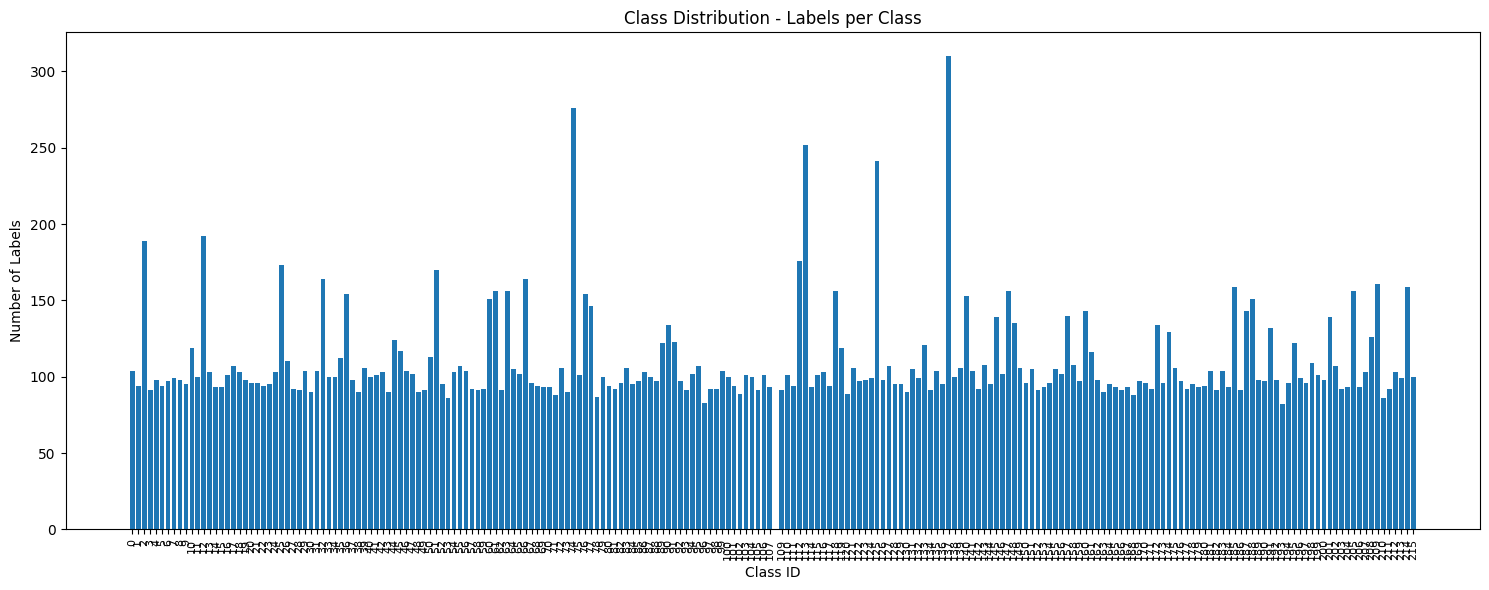

In [ ]:
# oversample underperforming classes
for cls in underperforming_classes:
    files = get_class_files(TRAIN_LABELS)
    oversample(files, 1, food_to_id[cls])


counts = count_all_classes()

plot_class_distribution(counts)

In [ ]:
for cls in underperforming_classes:
  print(f"{cls}: {counts[food_to_id[cls]]}")
#

apple: 189
beef-noodle-soup: 192
chicken-cutlet: 173
crape: 154
egg-sunny-side-up: 170
fried-fish: 156
green-salad: 276
grilled-eggplant: 154
japanese-tofu-and-vegetable-chowder: 134
miso-soup: 176
mixed-rice: 252
nanbanzuke: 156
orange: 241
pork-cutlet: 310
pork-with-lemon: 153
stewed-pork-leg: 159
teriyaki-grilled-fish: 139
tortilla: 156
vegetable-tempura: 161
yellow-curry: 159


In [ ]:
!roboflow login

visit https://app.roboflow.com/auth-cli to get your authentication token.
Paste the authentication token here: 


In [ ]:
!roboflow import -w caretechdavidadarshfinal -p david-bal-abl-oversample /content/V2-CareTech-Combined-Dataset-1/

Streaming output truncated to the last 5000 lines.
[UPLOADED] /content/V2-CareTech-Combined-Dataset-1/train/images/yusuf_2968_jpg.rf.00ff69b7b826a6a52dbe7ec436538d42.jpg (Q4qSSc7b1ZBgP7xNZXgV) [0.4s] / annotations = OK [0.4s]
[UPLOADED] /content/V2-CareTech-Combined-Dataset-1/train/images/yusuf_2972_jpg.rf.c66f1e7ff8a67afbdba0203ae6150312.jpg (CdYbliJ7SGIvs6Gh6Pc6) [0.5s] / annotations = OK [0.4s]
[UPLOADED] /content/V2-CareTech-Combined-Dataset-1/train/images/yusuf_297_jpg.rf.67b644d26c62822bd774bfbda5bc50ef.jpg (iK7QMhreQZ9jsxwGkdN5) [0.6s] / annotations = OK [0.4s]
[UPLOADED] /content/V2-CareTech-Combined-Dataset-1/train/images/yusuf_296_jpg.rf.d1782d069400e7386944d65b8982f61e.jpg (4m13EuE3JBn78FzhkhI2) [0.5s] / annotations = OK [0.7s]
[UPLOADED] /content/V2-CareTech-Combined-Dataset-1/train/images/yusuf_2979_jpg.rf.4cd1e8b4d392f931eb8e6f43ee201c31.jpg (hEuxcNNvAbRnRiIgYoYw) [0.5s] / annotations = OK [0.7s]
[UPLOADED] /content/V2-CareTech-Combined-Dataset-1/train/images/yusuf_2981_j

In [ ]:
project = rf.workspace("caretechdavidadarshfinal").project("david-bal-abl-oversample")
version = project.version(1)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to david-bal-abl-oversample-1 in yolo26:: 100%|██████████| 112664/112664 [00:08<00:00, 12678.49it/s]


In [ ]:
%pip install ultralytics
!yolo detect train data='/content/david-bal-abl-oversample-1/data.yaml' model=yolo26l.pt epochs=100 imgsz=640

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/david-bal-abl-oversample-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, 